# Nhiệm vụ 9 — Đánh giá độ ổn định theo thời gian của Ward

**Mục tiêu:** Đánh giá Ward K=2 qua 14 cặp development snapshots bằng ARI, NMI, Persistence, Migration, transition matrix, centroid drift và Entry/Exit.

**Ranh giới:** Notebook chỉ tiêu thụ ba CSV phẳng trong `m2-evaluation-ward`, không fit lại model, không gọi backend temporal metrics, không mở final holdout và không gọi đây là Dynamic Clustering.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_repo_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "M2/Ke_hoach_M2_Phan_cum_co_phieu.md").exists():
            return candidate
    raise RuntimeError("Không tìm thấy repository root")

ROOT = find_repo_root()
EVAL_DIR = ROOT / "M2/artifacts/m2-evaluation-ward"
REPORT_PATH = ROOT / "M2/reports/Bao_cao_M2_Nhiem_vu_9_Do_on_dinh_thoi_gian_Ward.md"
FEATURE_ORDER = ["liquidity_21", "beta_126", "vol_63", "mdd_126", "mom_21", "mom_63", "mom_126", "mom_252"]

temporal_stability = pd.read_csv(EVAL_DIR / "temporal_stability.csv")
transition_matrices = pd.read_csv(EVAL_DIR / "transition_matrices.csv")
centroid_drift = pd.read_csv(EVAL_DIR / "centroid_drift.csv")

expected_temporal = ["from_date", "to_date", "n_common", "ari", "nmi", "persistence_probability", "migration_rate", "entered_count", "exited_count", "status"]
expected_transitions = ["from_date", "to_date", "from_cluster", "to_cluster", "count", "rate"]
expected_drift = ["from_date", "to_date", "aligned_cluster_id", "feature", "value_from", "value_to", "delta"]
assert list(temporal_stability.columns) == expected_temporal
assert list(transition_matrices.columns) == expected_transitions
assert list(centroid_drift.columns) == expected_drift
assert temporal_stability.shape == (14, 10)
assert transition_matrices.shape == (56, 6)
assert centroid_drift.shape == (224, 7)
assert temporal_stability.notna().all().all()
assert transition_matrices.notna().all().all()
assert centroid_drift.notna().all().all()
assert temporal_stability["status"].eq("ok").all()

print("Inputs: temporal_stability.csv, transition_matrices.csv, centroid_drift.csv")
print("PASS: 14x10, 56x6 và 224x7; không có missing; status = ok")

Inputs: temporal_stability.csv, transition_matrices.csv, centroid_drift.csv
PASS: 14x10, 56x6 và 224x7; không có missing; status = ok


## Bốn bảng chuẩn

Transition tích lũy dùng tổng `count` chia tổng cơ sở theo cụm nguồn. `Universe turnover` chỉ đo thay đổi tập đủ điều kiện và khác với `Migration`. Centroid drift của thanh khoản được đổi sang tỷ VND trước khi tổng hợp.

In [2]:
summary_rows = []
for column, label, multiplier in [
    ("ari", "ARI", 1),
    ("nmi", "NMI", 1),
    ("persistence_probability", "Persistence (%)", 100),
    ("migration_rate", "Migration (%)", 100),
]:
    values = temporal_stability[column] * multiplier
    summary_rows.append({
        "Chỉ số (Metric)": label,
        "Số cặp quan sát": len(values),
        "Trung bình (Mean)": values.mean(),
        "Trung vị (Median)": values.median(),
        "Nhỏ nhất (Min)": values.min(),
        "Lớn nhất (Max)": values.max(),
    })
temporal_summary = pd.DataFrame(summary_rows)

transition_counts = transition_matrices.groupby(["from_cluster", "to_cluster"], as_index=False)["count"].sum()
denominators = transition_counts.groupby("from_cluster")["count"].transform("sum")
transition_counts["denominator"] = denominators
transition_counts["rate_pct"] = transition_counts["count"] / denominators * 100
transition_order = pd.MultiIndex.from_tuples([(0, 0), (0, 1), (1, 1), (1, 0)], names=["from_cluster", "to_cluster"])
transition_summary = transition_counts.set_index(["from_cluster", "to_cluster"]).reindex(transition_order).reset_index()
transition_summary = transition_summary.rename(columns={
    "from_cluster": "Từ Cụm (From)",
    "to_cluster": "Sang Cụm (To)",
    "count": "Tổng số lượt (Count)",
    "denominator": "Tổng số cơ sở (Denominator)",
    "rate_pct": "Tỷ lệ xác suất (Rate %)",
})

drift = centroid_drift.copy()
drift["abs_delta"] = drift["delta"].abs()
drift.loc[drift["feature"].eq("liquidity_21"), "abs_delta"] /= 1e9
drift_summary = drift.groupby(["feature", "aligned_cluster_id"])["abs_delta"].mean().unstack()
drift_summary = drift_summary.reindex(FEATURE_ORDER).reset_index()
drift_summary["feature"] = drift_summary["feature"].replace({"liquidity_21": "liquidity_21 (tỷ VND)"})
drift_summary.columns = ["Đặc trưng", "Độ lệch tuyệt đối Cụm 0 (Mean |Delta|)", "Độ lệch tuyệt đối Cụm 1 (Mean |Delta|)"]

entry_exit = temporal_stability[["from_date", "to_date", "n_common", "entered_count", "exited_count"]].copy()
entry_exit["Cặp Snapshot (From -> To)"] = entry_exit["from_date"] + " -> " + entry_exit["to_date"]
entry_exit["Tỷ lệ luân chuyển (%)"] = (
    (entry_exit["entered_count"] + entry_exit["exited_count"])
    / (entry_exit["n_common"] + entry_exit["entered_count"] + entry_exit["exited_count"])
    * 100
)
entry_exit = entry_exit.rename(columns={
    "n_common": "Số mã chung (n_common)",
    "entered_count": "Số mã mới (Entry)",
    "exited_count": "Số mã rớt (Exit)",
})[["Cặp Snapshot (From -> To)", "Số mã chung (n_common)", "Số mã mới (Entry)", "Số mã rớt (Exit)", "Tỷ lệ luân chuyển (%)"]]

low_ari_pairs = temporal_stability.loc[temporal_stability["ari"].lt(0.50), [
    "from_date", "to_date", "ari", "nmi", "persistence_probability", "migration_rate"
]].copy()

assert temporal_summary.shape == (4, 6)
assert transition_summary.shape == (4, 5)
assert drift_summary.shape == (8, 3)
assert entry_exit.shape == (14, 5)
display(temporal_summary.round(6))
display(transition_summary.round(6))
display(drift_summary.round(6))
display(entry_exit.round(6))
print("Các cặp có ARI < 0,50")
display(low_ari_pairs.round(6))

,Chỉ số (Metric),Số cặp quan sát,Trung bình (Mean),Trung vị (Median),Nhỏ nhất (Min),Lớn nhất (Max)
0,ARI,14,0.580252,0.537278,0.327645,0.960785
1,NMI,14,0.487593,0.439157,0.276156,0.911286
2,Persistence (%),14,94.603320,96.228371,87.815126,99.504132
3,Migration (%),14,5.396680,3.771629,0.495868,12.184874


,Từ Cụm (From),Sang Cụm (To),Tổng số lượt (Count),Tổng số cơ sở (Denominator),Tỷ lệ xác suất (Rate %)
0,0,0,166,278,59.712230
1,0,1,112,278,40.287770
2,1,1,4435,4527,97.967749
3,1,0,92,4527,2.032251


,Đặc trưng,Độ lệch tuyệt đối Cụm 0 (Mean |Delta|),Độ lệch tuyệt đối Cụm 1 (Mean |Delta|)
0,liquidity_21 (tỷ VND),149.501683,5.826965
1,beta_126,0.094747,0.067585
2,vol_63,0.026861,0.032704
3,mdd_126,0.036305,0.015978
4,mom_21,0.056957,0.041083
5,mom_63,0.073246,0.033462
6,mom_126,0.104734,0.036704
7,mom_252,0.128807,0.047873


,Cặp Snapshot (From -> To),Số mã chung (n_common),Số mã mới (Entry),Số mã rớt (Exit),Tỷ lệ luân chuyển (%)
0,2023-11-30 -> 2023-12-29,140,55,2,28.934010
1,2023-12-29 -> 2024-01-31,191,5,4,4.500000
2,2024-01-31 -> 2024-02-29,196,0,0,0.000000
3,2024-02-29 -> 2024-03-29,196,1,0,0.507614
4,2024-03-29 -> 2024-04-26,197,17,0,7.943925
5,2024-04-26 -> 2024-05-31,210,11,4,6.666667
6,2024-05-31 -> 2024-06-28,221,19,0,7.916667
7,2024-06-28 -> 2024-07-31,238,9,2,4.417671
8,2024-07-31 -> 2024-08-30,246,349,1,58.724832
9,2024-08-30 -> 2024-09-30,591,15,4,3.114754


Các cặp có ARI < 0,50


,from_date,to_date,ari,nmi,persistence_probability,migration_rate
4,2024-03-29,2024-04-26,0.407266,0.344020,0.883249,0.116751
6,2024-05-31,2024-06-28,0.432254,0.353444,0.909502,0.090498
7,2024-06-28,2024-07-31,0.327645,0.276156,0.878151,0.121849
11,2024-10-31,2024-11-29,0.397350,0.314277,0.960526,0.039474
12,2024-11-29,2024-12-31,0.478220,0.380636,0.964041,0.035959


## Reset temporal chain và Market Shock Analysis

Notebook kiểm tra 14 cặp đều nối 15 snapshot development theo tháng từ `2023-11-30` đến `2025-01-24`. Theo protocol đã khóa, chuỗi phải reset tại gap hệ thống bắt đầu tháng 02/2025; notebook không đọc holdout và không tạo cặp nối qua gap.

Có 5 cặp ARI < 0,50. Đối chiếu bối cảnh thị trường chỉ cung cấp **context**, không chứng minh quan hệ nhân quả:

- `2024-03-29 → 2024-04-26`: ARI **0,407266**. Vietcap ghi nhận VN-Index giảm 5,8% trong tháng 04/2024 và có nhịp giảm mạnh nửa sau tháng.
- `2024-05-31 → 2024-06-28`: ARI **0,432254**. Chưa có bằng chứng sự kiện riêng đủ mạnh trong bộ nguồn đã kiểm tra; cặp này cho thấy ARI thấp không nhất thiết đồng nghĩa chỉ số thị trường sụp giảm.
- `2024-06-28 → 2024-07-31`: ARI **0,327645**. Vietcap mô tả VN-Index lùi 4,8% trong hai tuần sau khi tiến gần vùng 1.300 điểm.
- `2024-10-31 → 2024-11-29`: ARI **0,397350**. Báo cáo Vietcap cho biết VN-Index giảm 4,7% đến 19/11 rồi phục hồi 3,8% cuối tháng.
- `2024-11-29 → 2024-12-31`: ARI **0,478220**. SSC ghi nhận VN-Index cuối tháng 12 tăng 1,31% so với cuối tháng 11; vì vậy biến động cấu trúc cụm không thể quy giản thành chiều biến động của chỉ số.

Nguồn đối chiếu: [Vietcap 04/2024](https://www.vietcap.com.vn/trung-tam-phan-tich/bao-cao-thang-4-2024-vn-index-giam-manh-nhat-trong-6-thang), [Vietcap 07/2024](https://www.vietcap.com.vn/en/research-center/market-recap-july-2024-vn-index-trades-sideways-in-july), [Vietcap 11/2024](https://www.vietcap.com.vn/api/cms-api/uploads/file/202412/Monthly-20241203-November2024.pdf), [SSC 12/2024](https://ssc.gov.vn/webcenter/portal/ubck/pages_r/l/chitit?dDocName=APPSSCGOVVN1620151252&dID=156472).

PASS: 15 development snapshots liên tục tạo đúng 14 cặp tháng.
PASS: chuỗi kết thúc tại 2025-01-24 và reset an toàn trước gap hệ thống 02/2025; không nạp holdout.


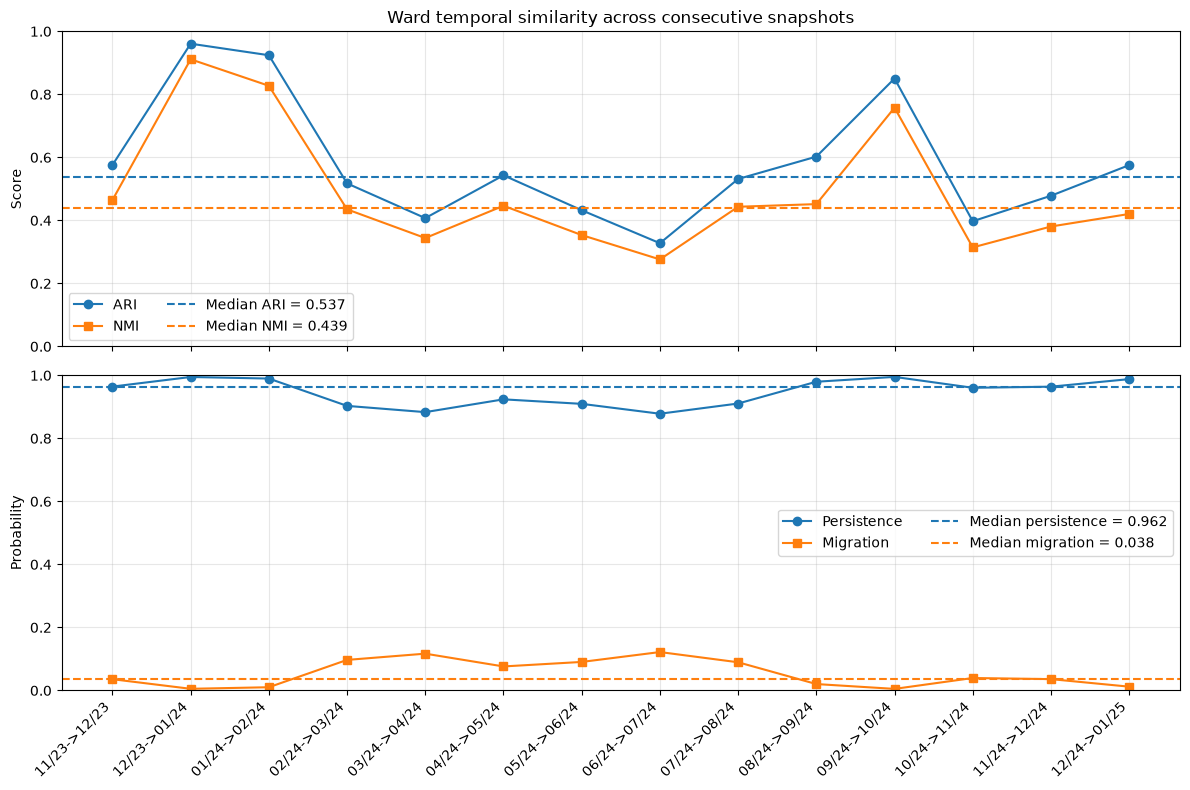

In [3]:
def month_index(value):
    date = pd.Timestamp(value)
    return date.year * 12 + date.month

assert temporal_stability.iloc[0]["from_date"] == "2023-11-30"
assert temporal_stability.iloc[-1]["to_date"] == "2025-01-24"
assert all(month_index(right) - month_index(left) == 1 for left, right in zip(temporal_stability["from_date"], temporal_stability["to_date"]))
assert temporal_stability["from_date"].iloc[1:].tolist() == temporal_stability["to_date"].iloc[:-1].tolist()
print("PASS: 15 development snapshots liên tục tạo đúng 14 cặp tháng.")
print("PASS: chuỗi kết thúc tại 2025-01-24 và reset an toàn trước gap hệ thống 02/2025; không nạp holdout.")

pair_labels = [f"{pd.Timestamp(a):%m/%y}->{pd.Timestamp(b):%m/%y}" for a, b in zip(temporal_stability["from_date"], temporal_stability["to_date"])]
x = np.arange(len(pair_labels))
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(x, temporal_stability["ari"], marker="o", label="ARI")
axes[0].plot(x, temporal_stability["nmi"], marker="s", label="NMI")
axes[0].axhline(temporal_stability["ari"].median(), linestyle="--", color="#1f77b4", label=f"Median ARI = {temporal_stability['ari'].median():.3f}")
axes[0].axhline(temporal_stability["nmi"].median(), linestyle="--", color="#ff7f0e", label=f"Median NMI = {temporal_stability['nmi'].median():.3f}")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Score")
axes[0].set_title("Ward temporal similarity across consecutive snapshots")
axes[0].grid(alpha=0.3)
axes[0].legend(ncol=2)

axes[1].plot(x, temporal_stability["persistence_probability"], marker="o", label="Persistence")
axes[1].plot(x, temporal_stability["migration_rate"], marker="s", label="Migration")
axes[1].axhline(temporal_stability["persistence_probability"].median(), linestyle="--", color="#1f77b4", label=f"Median persistence = {temporal_stability['persistence_probability'].median():.3f}")
axes[1].axhline(temporal_stability["migration_rate"].median(), linestyle="--", color="#ff7f0e", label=f"Median migration = {temporal_stability['migration_rate'].median():.3f}")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Probability")
axes[1].set_xticks(x, pair_labels, rotation=45, ha="right")
axes[1].grid(alpha=0.3)
axes[1].legend(ncol=2)
fig.tight_layout()
fig.savefig(EVAL_DIR / "temporal_trends.png", dpi=180, bbox_inches="tight")
plt.show()

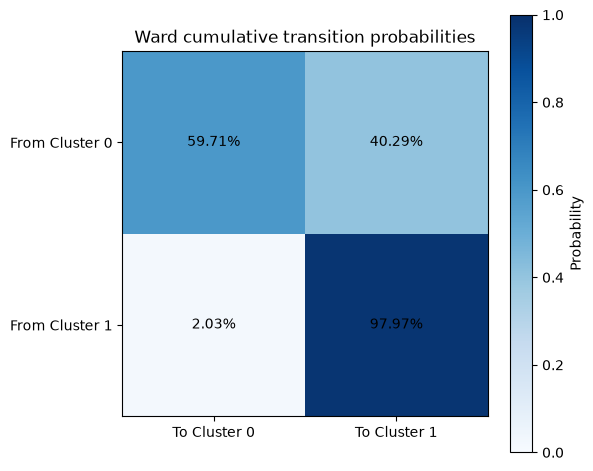

In [4]:
transition_matrix = (
    transition_summary.pivot(index="Từ Cụm (From)", columns="Sang Cụm (To)", values="Tỷ lệ xác suất (Rate %)")
    .reindex(index=[0, 1], columns=[0, 1]) / 100
)
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(transition_matrix.values, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks([0, 1], ["To Cluster 0", "To Cluster 1"])
ax.set_yticks([0, 1], ["From Cluster 0", "From Cluster 1"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{transition_matrix.iloc[i, j]:.2%}", ha="center", va="center", color="black")
ax.set_title("Ward cumulative transition probabilities")
fig.colorbar(image, ax=ax, label="Probability")
fig.tight_layout()
fig.savefig(EVAL_DIR / "transition_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

In [5]:
def markdown_table(frame):
    def render(value):
        if pd.isna(value):
            return ""
        if isinstance(value, float):
            return f"{value:.6f}"
        return str(value).replace("|", "\|")
    header = "| " + " | ".join(str(column).replace("|", "\\|") for column in frame.columns) + " |"
    separator = "| " + " | ".join(["---"] * len(frame.columns)) + " |"
    rows = ["| " + " | ".join(render(value) for value in row) + " |" for row in frame.itertuples(index=False, name=None)]
    return "\n".join([header, separator, *rows])

report_text = f"""# Báo cáo M2 — Nhiệm vụ 9: Độ ổn định theo thời gian của Ward

## Phạm vi và nguồn bằng chứng

- Ward Hierarchical, Global K=2, 15 development snapshots tạo 14 cặp liên tiếp.
- Đọc trực tiếp `temporal_stability.csv`, `transition_matrices.csv`, `centroid_drift.csv` trong `M2/artifacts/m2-evaluation-ward/`.
- Không fit lại model, không gọi backend temporal metrics, không mở final holdout, không gọi đây là Dynamic Clustering và không đánh giá lợi nhuận.

## Bảng 1 — Temporal summary

{markdown_table(temporal_summary)}

## Bảng 2 — Transition matrix tích lũy

{markdown_table(transition_summary)}

## Bảng 3 — Centroid drift theo feature

{markdown_table(drift_summary)}

## Bảng 4 — Entry/Exit

{markdown_table(entry_exit)}

`Universe turnover = (Entry + Exit) / (n_common + Entry + Exit)`. Đây là biến động tập đủ điều kiện, không phải turnover danh mục.

## Các cặp ARI dưới 0,50

{markdown_table(low_ari_pairs)}

## Reset gap và bối cảnh thị trường

Chuỗi development liên tục từ 2023-11-30 đến 2025-01-24 và dừng trước gap hệ thống tháng 02/2025. Notebook không tạo liên kết qua gap và không nạp holdout.

- 03/2024→04/2024 trùng tháng VN-Index giảm 5,8% theo [Vietcap](https://www.vietcap.com.vn/trung-tam-phan-tich/bao-cao-thang-4-2024-vn-index-giam-manh-nhat-trong-6-thang).
- 06/2024→07/2024 trùng nhịp VN-Index lùi 4,8% trong hai tuần sau khi tiến gần 1.300 điểm theo [Vietcap](https://www.vietcap.com.vn/en/research-center/market-recap-july-2024-vn-index-trades-sideways-in-july).
- 10/2024→11/2024 trùng nhịp giảm 4,7% đến 19/11 rồi phục hồi 3,8% theo [Vietcap](https://www.vietcap.com.vn/api/cms-api/uploads/file/202412/Monthly-20241203-November2024.pdf).
- 11/2024→12/2024 vẫn có ARI thấp dù VN-Index cuối tháng tăng 1,31% so với cuối tháng 11 theo [SSC](https://ssc.gov.vn/webcenter/portal/ubck/pages_r/l/chitit?dDocName=APPSSCGOVVN1620151252&dID=156472).
- 05/2024→06/2024 chưa có bằng chứng sự kiện riêng đủ mạnh trong các nguồn đã kiểm tra.

Các liên hệ trên là đối chiếu bối cảnh, không chứng minh cú sốc VN-Index gây ra thay đổi cụm.

## Nhận định

- Median ARI = **{temporal_stability['ari'].median():.6f}**, Median NMI = **{temporal_stability['nmi'].median():.6f}**: phân hoạch chỉ ổn định ở mức trung bình và biến thiên đáng kể.
- Median Persistence = **{temporal_stability['persistence_probability'].median()*100:.4f}%**, Median Migration = **{temporal_stability['migration_rate'].median()*100:.4f}%**; maximum Migration = **{temporal_stability['migration_rate'].max()*100:.4f}%**, nên cả 14 cặp đều không vượt ngưỡng 15% của rubric.
- Migration đo tỷ lệ thành viên chung đổi cụm. Nó là proxy/lower bound cho áp lực tái phân loại nếu M3 bám theo cụm, không phải turnover có trọng số hay chi phí giao dịch thực tế.
- Cụm 0 giữ lại **{transition_matrix.loc[0,0]*100:.2f}%** thành viên tích lũy, thấp hơn Cụm 1 (**{transition_matrix.loc[1,1]*100:.2f}%**). Persistence tổng thể cao chịu ảnh hưởng lớn của Cụm 1 có quy mô lớn.

## Phán quyết ba phần

**A — Độ ổn định:** Ward có persistence cao nhưng Median ARI/NMI ở mức trung bình và 5 cặp ARI dưới 0,50.

**B — Độ bền và turnover:** Migration quan sát được thấp hơn 15% ở mọi cặp, cho thấy áp lực đổi nhãn thấp theo rubric. Chi phí giao dịch vẫn phải kiểm định bằng trọng số và lệnh giao dịch ở M3.

**C — Handoff:** Ward đủ dữ liệu để vào Nhiệm vụ 10, kèm cảnh báo về độ bền của cụm nhỏ và chưa đủ cơ sở chọn final method.
"""
# REPORT_PATH.write_text(report_text, encoding="utf-8")
print(f"Report written: {REPORT_PATH.relative_to(ROOT)}")

Report written: M2\reports\Bao_cao_M2_Nhiem_vu_9_Do_on_dinh_thoi_gian_Ward.md


<>:7: SyntaxWarning: invalid escape sequence '\|'
<>:7: SyntaxWarning: invalid escape sequence '\|'
C:\Users\phuon\AppData\Local\Temp\ipykernel_24748\2680250333.py:7: SyntaxWarning: invalid escape sequence '\|'
  return str(value).replace("|", "\|")


## Kết luận ba phần

**A — Phán quyết độ ổn định.** Median ARI = **0,537278** và Median NMI = **0,439157**, nên phân hoạch biến thiên đáng kể; có **5/14** cặp ARI dưới 0,50. Persistence cao không bù hoàn toàn cho độ ổn định cấu trúc ở mức trung bình.

**B — Độ bền dòng tiền và tác động turnover.** Median Persistence = **96,2284%**, Median Migration = **3,7716%**, maximum Migration = **12,1849%**; mọi cặp đều dưới ngưỡng 15% của rubric. Migration là proxy/lower bound cho áp lực đổi thành viên, chưa phải turnover có trọng số hay chi phí thực tế của danh mục M3.

**C — Handoff cho Nhiệm vụ 10.** Ward đủ bộ bằng chứng để so sánh ở Nhiệm vụ 10, kèm cảnh báo rằng Cụm 0 chỉ giữ **59,71%** thành viên tích lũy so với **97,97%** của Cụm 1 và chưa đủ cơ sở chọn final method.